In [ ]:
import os

# Disable TF/Flax to avoid pulling in tensorflow and problematic protobuf
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Use absolute path to the model folder
MODEL_PATH = "/Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_model/my-finetuned-ner-400-2nd-model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH)



Device set to use cpu


Model loaded successfully!


In [16]:
ner_pipeline = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="max",
    device=-1,  # CPU; change to 0 if you have a CUDA GPU and proper setup
)

print("Model loaded successfully!")


Device set to use cpu


Model loaded successfully!


In [3]:
text = """
Wir suchen einen Machine Learning Engineer mit Erfahrung in Python,
TensorFlow, SQL, Data Pipelines, Docker und MLflow.
"""

output = ner_pipeline(text)

for ent in output:
    print(ent["word"], ent["score"])

Wir 0.86927
such 0.94669527
Machine Learning 0.90288067
Engineer 0.9734239
Er 0.9706458
##fahrung 0.75301325
Python 0.8493746
##sor 0.9589897
SQL 0.7017754
Pipeli 0.1017046
##nes 0.70172274
Dock 0.03256691
##er 0.11417576


In [21]:
import re
from nltk.corpus import stopwords
import nltk
# Download stopwords if not already present
nltk.download('stopwords', quiet=True)

german_stopwords = set(stopwords.words('german'))
english_stopwords = set(stopwords.words('english'))

# Combine both German and English stopwords
stopwords = german_stopwords.union(english_stopwords)

# merge with existing STOPWORDS defined later (from cell 4)
# note: this creates a new combined set; we won't overwrite the later STOPWORDS
STOPWORDS = stopwords
def clean_skill(token: str):
    token = token.strip()

    # Remove subword tokens
    if token.startswith("##"):
        return None

    # Lowercase normalize
    t = token.lower()

    # Remove stopwords
    if t in STOPWORDS:
        return None
    
    # Remove tokens < 3 chars
    if len(t) < 3:
        return None

    # Remove punctuation-only tokens
    if not re.search("[a-zA-Z0-9]", t):
        return None

    return token


In [22]:


def clean_token(token):
    t = token.lower().strip()

    if t.startswith("##"):
        return None

    if len(t) < 3:
        return None

    if t in STOPWORDS:
        return None

    if not re.search("[a-z0-9]", t):
        return None

    return t


In [23]:
import pandas as pd

df = pd.read_csv("/Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/dataset/jobs_ai_ml_with_city_state_filled.csv")

# Ensure correct column names:
assert "year" in df.columns
assert "job_text" in df.columns
assert "city" in df.columns
assert "state" in df.columns


In [67]:
import json
from tqdm import tqdm

with open("/Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/dataset/skillsTable.json", "r") as f:
    taxonomy = json.load(f)["skill_dict"]
# Create a normalized set of valid skills
VALID_SKILLS = set()

for category, subcats in taxonomy.items():
    for subcat, keywords in subcats.items():
        for kw in keywords:
            VALID_SKILLS.add(kw.lower().strip())
            # normalization
            VALID_SKILLS.add(re.sub(r"[^a-z0-9]", "", kw.lower()))
            
def is_valid_skill(token):
    if token in VALID_SKILLS:
        return True

    # Try normalized match
    t_norm = re.sub(r"[^a-z0-9]", "", token)
    return t_norm in VALID_SKILLS


# Build reverse map: keyword → (category, subcategory)
KEYWORD_TO_CATEGORY = {}

for cat, subcats in taxonomy.items():
    for subcat, keywords in subcats.items():
        for kw in keywords:
            KEYWORD_TO_CATEGORY[kw.lower().strip()] = (cat, subcat)
            k_norm = re.sub(r"[^a-z0-9]", "", kw.lower())
            KEYWORD_TO_CATEGORY[k_norm] = (cat, subcat)

def map_skill(token):
    token = token.lower().strip()
    t_norm = re.sub(r"[^a-z0-9]", "", token)

    if token in KEYWORD_TO_CATEGORY:
        return KEYWORD_TO_CATEGORY[token]
    if t_norm in KEYWORD_TO_CATEGORY:
        return KEYWORD_TO_CATEGORY[t_norm]

    return ("Uncategorized", "Uncategorized")

# ------------------------------------------------------
# Extract skills from dataset
# ------------------------------------------------------
records = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    text = str(row["job_text"])
    ner_output = ner_pipeline(text)

    for ent in ner_output:
        raw_skill = ent["word"]
        cleaned = clean_token(raw_skill)

        if not cleaned:
            continue

        if not is_valid_skill(cleaned):
            continue

        category, subcat = map_skill(cleaned)

        records.append({
            "year": row["year"],
            "city": row["city"],
            "state": row["state"],
            "skill": cleaned,
            "category": category,
            "subcategory": subcat
        })


skill_df = pd.DataFrame(records)

# Save to the new results folder
output_file = os.path.join(raw_data_dir, "skill_extractions_full.csv")
skill_df.to_csv(output_file, index=False)

print(f"✔ Skill extraction complete!")
print(f"  Saved to: {output_file}")
print(f"  Total records: {len(skill_df)}")


100%|██████████| 1444/1444 [01:46<00:00, 13.55it/s]

✔ Skill extraction complete!
  Saved to: /Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_analysis/results/raw_data/skill_extractions_full.csv
  Total records: 14157


In [25]:
from collections import Counter

skills_2019 = Counter(skill_df[skill_df["year"] == 2019]["skill"].str.lower())
skills_2025 = Counter(skill_df[skill_df["year"] == 2025]["skill"].str.lower())

pd.DataFrame(skills_2019.most_common(50)).to_csv("top_skills_2019.csv", index=False)
pd.DataFrame(skills_2025.most_common(50)).to_csv("top_skills_2025.csv", index=False)


In [26]:
cat_2019 = Counter(skill_df[skill_df["year"] == 2019]["category"])
cat_2025 = Counter(skill_df[skill_df["year"] == 2025]["category"])

pd.DataFrame(cat_2019.most_common()).to_csv("top_categories_2019.csv", index=False)
pd.DataFrame(cat_2025.most_common()).to_csv("top_categories_2025.csv", index=False)


In [33]:
city_counts = skill_df["city"].value_counts().reset_index()
city_counts.columns = ["city", "count"]
city_counts.to_csv("city_distribution.csv", index=False)

state_counts = skill_df["state"].value_counts().reset_index()
state_counts.columns = ["state", "count"]
state_counts.to_csv("state_distribution.csv", index=False)


In [31]:
# Debug: Check the data first
print(f"Total records in skill_df: {len(skill_df)}")
print(f"Years available: {skill_df['year'].unique()}")
print(f"Records in 2019: {len(skill_df[skill_df['year'] == 2019])}")
print(f"Records in 2025: {len(skill_df[skill_df['year'] == 2025])}")
print(f"\nSample of data:")
print(skill_df[["year", "city", "state", "skill"]].head(10))

Total records in skill_df: 14237
Years available: [2019 2025]
Records in 2019: 7690
Records in 2025: 6547

Sample of data:
   year       city                state             skill
0  2019       Köln  Nordrhein-Westfalen               nlp
1  2019       Köln  Nordrhein-Westfalen            python
2  2019  Bielefeld  Nordrhein-Westfalen    verantwortlich
3  2019  Bielefeld  Nordrhein-Westfalen       integration
4  2019  Bielefeld  Nordrhein-Westfalen           analyse
5  2019  Bielefeld  Nordrhein-Westfalen    zusammenarbeit
6  2019       Köln  Nordrhein-Westfalen  machine learning
7  2019       Köln  Nordrhein-Westfalen        analytisch
8  2019       Köln  Nordrhein-Westfalen  machine learning
9  2019       Köln  Nordrhein-Westfalen         statistik


In [34]:
# Create year-specific distributions
city_2019 = skill_df[skill_df["year"] == 2019]["city"].value_counts().reset_index()
city_2019.columns = ["city", "count"]
city_2019.to_csv("city_distribution_2019.csv", index=False)
print("Created city_distribution_2019.csv")

city_2025 = skill_df[skill_df["year"] == 2025]["city"].value_counts().reset_index()
city_2025.columns = ["city", "count"]
city_2025.to_csv("city_distribution_2025.csv", index=False)
print("Created city_distribution_2025.csv")

state_2019 = skill_df[skill_df["year"] == 2019]["state"].value_counts().reset_index()
state_2019.columns = ["state", "count"]
state_2019.to_csv("state_distribution_2019.csv", index=False)
print("Created state_distribution_2019.csv")

state_2025 = skill_df[skill_df["year"] == 2025]["state"].value_counts().reset_index()
state_2025.columns = ["state", "count"]
state_2025.to_csv("state_distribution_2025.csv", index=False)
print("Created state_distribution_2025.csv")

print(f"\nTop 5 Cities in 2019:")
print(city_2019.head())
print(f"\nTop 5 Cities in 2025:")
print(city_2025.head())
print(f"\nTop 5 States in 2019:")
print(state_2019.head())
print(f"\nTop 5 States in 2025:")
print(state_2025.head())

Created city_distribution_2019.csv
Created city_distribution_2025.csv
Created state_distribution_2019.csv
Created state_distribution_2025.csv

Top 5 Cities in 2019:
                city  count
0               Köln   2162
1            München    662
2             Berlin    605
3  Frankfurt am Main    576
4          Stuttgart    474

Top 5 Cities in 2025:
                city  count
0             Berlin   1194
1            München   1053
2               Köln    483
3         Düsseldorf    310
4  Frankfurt am Main    279

Top 5 States in 2019:
                 state  count
0  Nordrhein-Westfalen   3417
1    Baden-Württemberg   1103
2               Bayern    906
3               Hessen    679
4               Berlin    605

Top 5 States in 2025:
                 state  count
0  Nordrhein-Westfalen   1432
1               Bayern   1430
2               Berlin   1194
3    Baden-Württemberg   1028
4               Hessen    416


In [35]:
# Check the original dataframe for job_domain_keywords
print("Checking job_domain_keywords column:")
print(df[["year", "city", "state", "job_domain_keywords"]].head(10))
print(f"\nUnique job_domain_keywords values:")
print(df["job_domain_keywords"].value_counts())

Checking job_domain_keywords column:
   year               city                state  \
0  2019               Köln  Nordrhein-Westfalen   
1  2019          Bielefeld  Nordrhein-Westfalen   
2  2019               Köln  Nordrhein-Westfalen   
3  2019               Köln  Nordrhein-Westfalen   
4  2019  Frankfurt am Main               Hessen   
5  2019          Esslingen    Baden-Württemberg   
6  2019          Esslingen    Baden-Württemberg   
7  2019          Esslingen    Baden-Württemberg   
8  2019            München               Bayern   
9  2019               Köln  Nordrhein-Westfalen   

                         job_domain_keywords  
0  machine learning, artificial intelligence  
1                           machine learning  
2  machine learning, artificial intelligence  
3  machine learning, artificial intelligence  
4                           machine learning  
5  machine learning, artificial intelligence  
6  machine learning, artificial intelligence  
7  machine learning, arti

In [68]:
# Re-extract skills with job domain information
# This time we'll keep track of whether each job is AI, ML, or both

records_with_domain = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting skills with domain info"):
    text = str(row["job_text"])
    ner_output = ner_pipeline(text)
    
    # Parse job_domain_keywords
    domain_keywords = str(row["job_domain_keywords"]).lower()
    has_ai = "artificial intelligence" in domain_keywords
    has_ml = "machine learning" in domain_keywords
    
    # Determine job type
    if has_ai and has_ml:
        job_type = "Both AI & ML"
    elif has_ai:
        job_type = "AI"
    elif has_ml:
        job_type = "ML"
    else:
        job_type = "Other"

    for ent in ner_output:
        raw_skill = ent["word"]
        cleaned = clean_token(raw_skill)

        if not cleaned:
            continue

        if not is_valid_skill(cleaned):
            continue

        category, subcat = map_skill(cleaned)

        records_with_domain.append({
            "year": row["year"],
            "city": row["city"],
            "state": row["state"],
            "skill": cleaned,
            "category": category,
            "subcategory": subcat,
            "job_type": job_type  # AI, ML, or Both
        })

skill_df_with_domain = pd.DataFrame(records_with_domain)

# Save to the new results folder
output_file = os.path.join(raw_data_dir, "skill_extractions_with_domain.csv")
skill_df_with_domain.to_csv(output_file, index=False)

print(f"✔ Skill extraction with domain complete!")
print(f"  Saved to: {output_file}")
print(f"  Total records: {len(skill_df_with_domain)}")
print(f"\nJob type distribution:")
print(skill_df_with_domain["job_type"].value_counts())

Extracting skills with domain info: 100%|██████████| 1444/1444 [01:41<00:00, 14.20it/s]

✔ Skill extraction with domain complete!
  Saved to: /Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_analysis/results/raw_data/skill_extractions_with_domain.csv
  Total records: 14157

Job type distribution:
job_type
Both AI & ML    12759
ML                844
AI                554
Name: count, dtype: int64


In [69]:
# Create separate distributions for AI and ML jobs by year and location

# Filter for AI jobs (including "Both AI & ML" since those are AI jobs too)
ai_jobs = skill_df_with_domain[skill_df_with_domain["job_type"].isin(["AI", "Both AI & ML"])]

# Filter for ML jobs (including "Both AI & ML" since those are ML jobs too)
ml_jobs = skill_df_with_domain[skill_df_with_domain["job_type"].isin(["ML", "Both AI & ML"])]

print(f"AI jobs total: {len(ai_jobs)}")
print(f"ML jobs total: {len(ml_jobs)}")

# ===== AI DISTRIBUTIONS =====

# AI - State distributions by year
ai_state_2019 = ai_jobs[ai_jobs["year"] == 2019]["state"].value_counts().reset_index()
ai_state_2019.columns = ["state", "count"]
ai_state_2019.to_csv(os.path.join(distributions_dir, "state_distribution_AI_2019.csv"), index=False)

ai_state_2025 = ai_jobs[ai_jobs["year"] == 2025]["state"].value_counts().reset_index()
ai_state_2025.columns = ["state", "count"]
ai_state_2025.to_csv(os.path.join(distributions_dir, "state_distribution_AI_2025.csv"), index=False)

# AI - City distributions by year
ai_city_2019 = ai_jobs[ai_jobs["year"] == 2019]["city"].value_counts().reset_index()
ai_city_2019.columns = ["city", "count"]
ai_city_2019.to_csv(os.path.join(distributions_dir, "city_distribution_AI_2019.csv"), index=False)

ai_city_2025 = ai_jobs[ai_jobs["year"] == 2025]["city"].value_counts().reset_index()
ai_city_2025.columns = ["city", "count"]
ai_city_2025.to_csv(os.path.join(distributions_dir, "city_distribution_AI_2025.csv"), index=False)

# ===== ML DISTRIBUTIONS =====

# ML - State distributions by year
ml_state_2019 = ml_jobs[ml_jobs["year"] == 2019]["state"].value_counts().reset_index()
ml_state_2019.columns = ["state", "count"]
ml_state_2019.to_csv(os.path.join(distributions_dir, "state_distribution_ML_2019.csv"), index=False)

ml_state_2025 = ml_jobs[ml_jobs["year"] == 2025]["state"].value_counts().reset_index()
ml_state_2025.columns = ["state", "count"]
ml_state_2025.to_csv(os.path.join(distributions_dir, "state_distribution_ML_2025.csv"), index=False)

# ML - City distributions by year
ml_city_2019 = ml_jobs[ml_jobs["year"] == 2019]["city"].value_counts().reset_index()
ml_city_2019.columns = ["city", "count"]
ml_city_2019.to_csv(os.path.join(distributions_dir, "city_distribution_ML_2019.csv"), index=False)

ml_city_2025 = ml_jobs[ml_jobs["year"] == 2025]["city"].value_counts().reset_index()
ml_city_2025.columns = ["city", "count"]
ml_city_2025.to_csv(os.path.join(distributions_dir, "city_distribution_ML_2025.csv"), index=False)

print("\n✔ Created AI and ML specific distributions!")
print("\nFiles created in distributions folder:")
print("  AI - 2019:")
print("    - state_distribution_AI_2019.csv")
print("    - city_distribution_AI_2019.csv")
print("  AI - 2025:")
print("    - state_distribution_AI_2025.csv")
print("    - city_distribution_AI_2025.csv")
print("  ML - 2019:")
print("    - state_distribution_ML_2019.csv")
print("    - city_distribution_ML_2019.csv")
print("  ML - 2025:")
print("    - state_distribution_ML_2025.csv")
print("    - city_distribution_ML_2025.csv")

print("\n" + "="*60)
print("AI JOBS - TOP 5 STATES BY YEAR")
print("="*60)
print("\nAI 2019 - Top 5 States:")
print(ai_state_2019.head())
print("\nAI 2025 - Top 5 States:")
print(ai_state_2025.head())

print("\n" + "="*60)
print("ML JOBS - TOP 5 STATES BY YEAR")
print("="*60)
print("\nML 2019 - Top 5 States:")
print(ml_state_2019.head())
print("\nML 2025 - Top 5 States:")
print(ml_state_2025.head())

print("\n" + "="*60)
print("AI JOBS - TOP 5 CITIES BY YEAR")
print("="*60)
print("\nAI 2019 - Top 5 Cities:")
print(ai_city_2019.head())
print("\nAI 2025 - Top 5 Cities:")
print(ai_city_2025.head())

print("\n" + "="*60)
print("ML JOBS - TOP 5 CITIES BY YEAR")
print("="*60)
print("\nML 2019 - Top 5 Cities:")
print(ml_city_2019.head())
print("\nML 2025 - Top 5 Cities:")
print(ml_city_2025.head())

AI jobs total: 13313
ML jobs total: 13603

✔ Created AI and ML specific distributions!

Files created in distributions folder:
  AI - 2019:
    - state_distribution_AI_2019.csv
    - city_distribution_AI_2019.csv
  AI - 2025:
    - state_distribution_AI_2025.csv
    - city_distribution_AI_2025.csv
  ML - 2019:
    - state_distribution_ML_2019.csv
    - city_distribution_ML_2019.csv
  ML - 2025:
    - state_distribution_ML_2025.csv
    - city_distribution_ML_2025.csv

AI JOBS - TOP 5 STATES BY YEAR

AI 2019 - Top 5 States:
                 state  count
0  Nordrhein-Westfalen   3002
1    Baden-Württemberg    993
2               Bayern    813
3               Hessen    627
4               Berlin    566

AI 2025 - Top 5 States:
                 state  count
0  Nordrhein-Westfalen   1407
1               Bayern   1406
2               Berlin   1179
3    Baden-Württemberg    965
4               Hessen    415

ML JOBS - TOP 5 STATES BY YEAR

ML 2019 - Top 5 States:
                 state  count


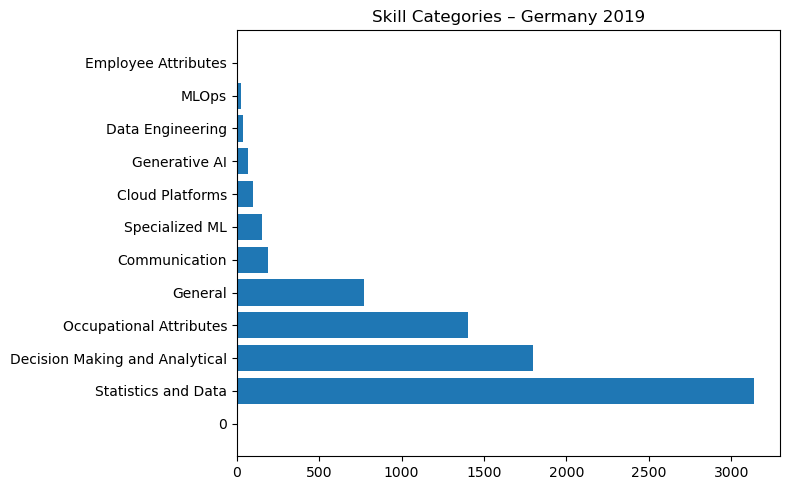

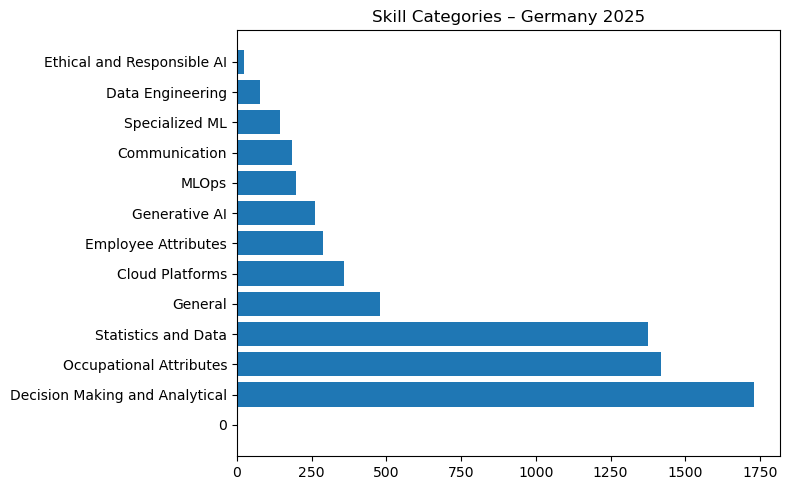

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df_2019 = pd.read_csv("top_categories_2019.csv", header=None, names=["category", "count"])
df_2025 = pd.read_csv("top_categories_2025.csv", header=None, names=["category", "count"])

plt.figure(figsize=(8,5))
plt.barh(df_2019["category"], df_2019["count"])
plt.title("Skill Categories – Germany 2019")
plt.tight_layout()
plt.savefig("plot_categories_2019.pdf")

plt.figure(figsize=(8,5))
plt.barh(df_2025["category"], df_2025["count"])
plt.title("Skill Categories – Germany 2025")
plt.tight_layout()
plt.savefig("plot_categories_2025.pdf")


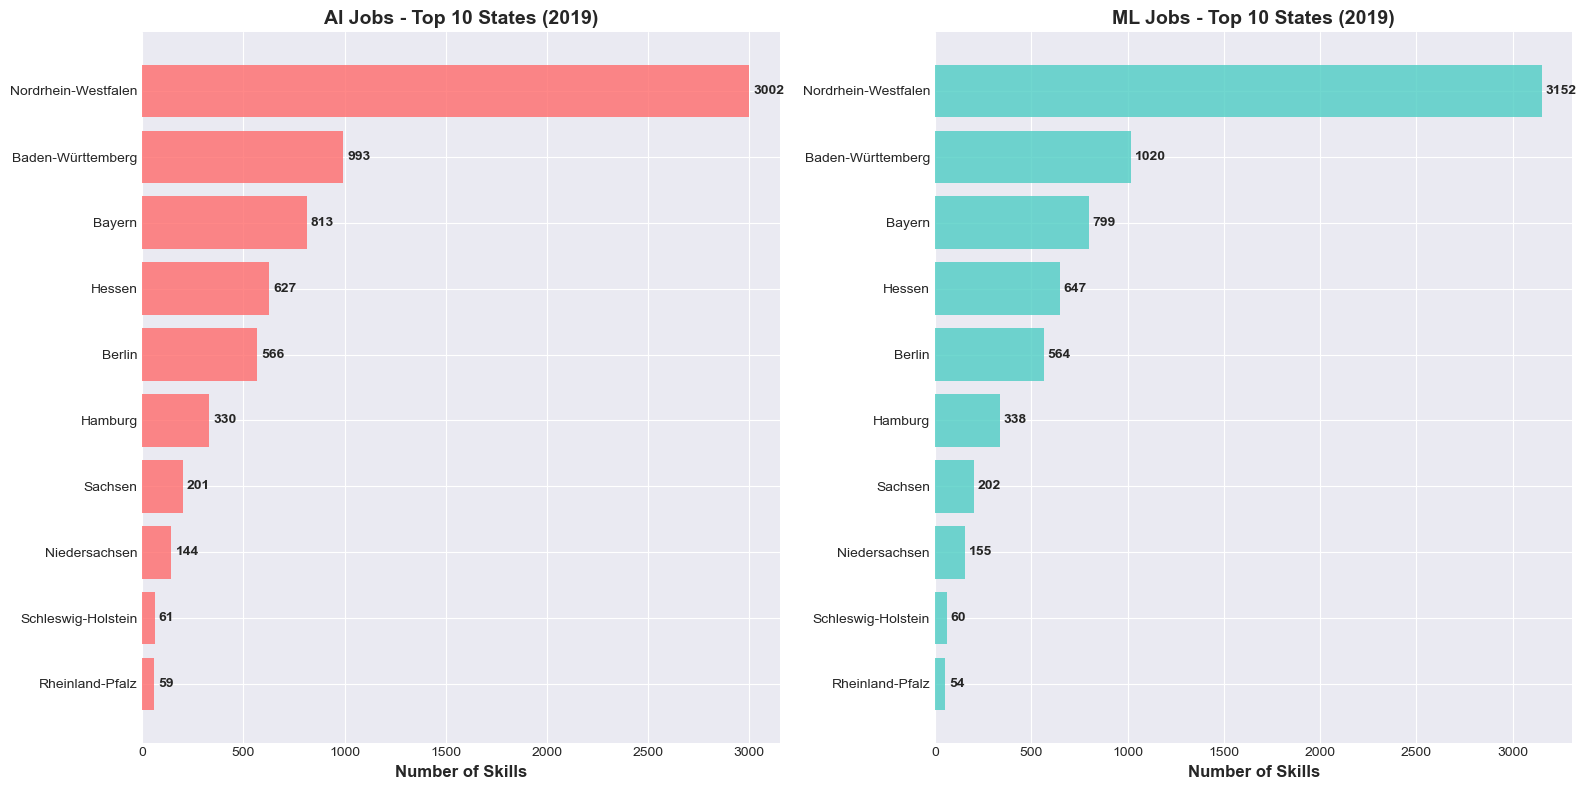

✔ Created: comparison_states_AI_vs_ML_2019.pdf/png


In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================
# 1. STATE COMPARISON - AI vs ML for 2019
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# AI States 2019
top_ai_2019 = ai_state_2019.head(10)
ax1.barh(top_ai_2019['state'], top_ai_2019['count'], color='#FF6B6B', alpha=0.8)
ax1.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax1.set_title('AI Jobs - Top 10 States (2019)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top_ai_2019['count']):
    ax1.text(v + 20, i, str(v), va='center', fontweight='bold')

# ML States 2019
top_ml_2019 = ml_state_2019.head(10)
ax2.barh(top_ml_2019['state'], top_ml_2019['count'], color='#4ECDC4', alpha=0.8)
ax2.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax2.set_title('ML Jobs - Top 10 States (2019)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(top_ml_2019['count']):
    ax2.text(v + 20, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'comparison_states_AI_vs_ML_2019.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'comparison_states_AI_vs_ML_2019.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: comparison_states_AI_vs_ML_2019.pdf/png")

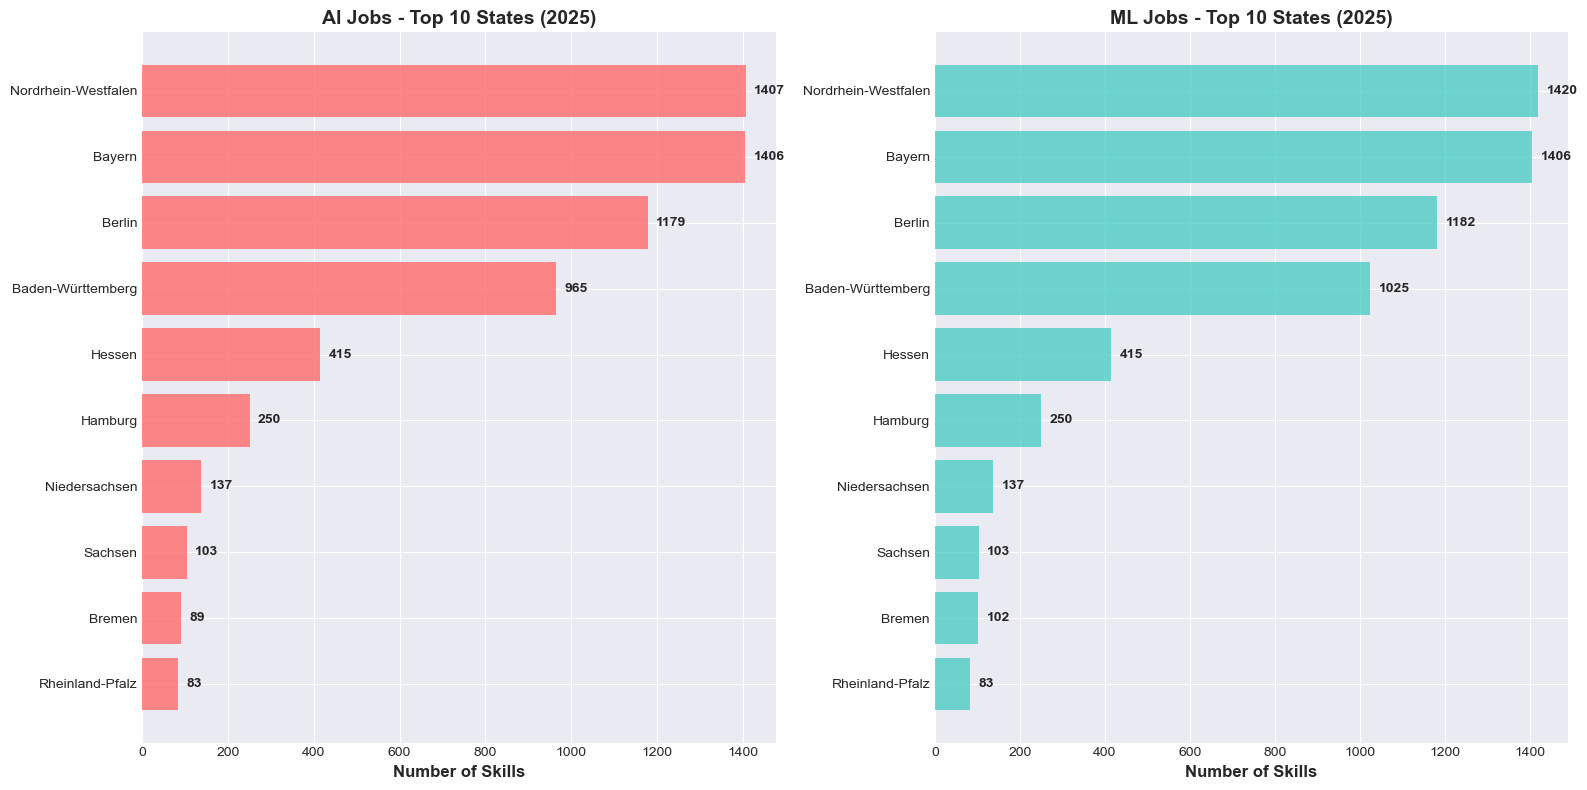

✔ Created: comparison_states_AI_vs_ML_2025.pdf/png


In [75]:
# ============================================================
# 2. STATE COMPARISON - AI vs ML for 2025
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# AI States 2025
top_ai_2025 = ai_state_2025.head(10)
ax1.barh(top_ai_2025['state'], top_ai_2025['count'], color='#FF6B6B', alpha=0.8)
ax1.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax1.set_title('AI Jobs - Top 10 States (2025)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top_ai_2025['count']):
    ax1.text(v + 20, i, str(v), va='center', fontweight='bold')

# ML States 2025
top_ml_2025 = ml_state_2025.head(10)
ax2.barh(top_ml_2025['state'], top_ml_2025['count'], color='#4ECDC4', alpha=0.8)
ax2.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax2.set_title('ML Jobs - Top 10 States (2025)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(top_ml_2025['count']):
    ax2.text(v + 20, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'comparison_states_AI_vs_ML_2025.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'comparison_states_AI_vs_ML_2025.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: comparison_states_AI_vs_ML_2025.pdf/png")

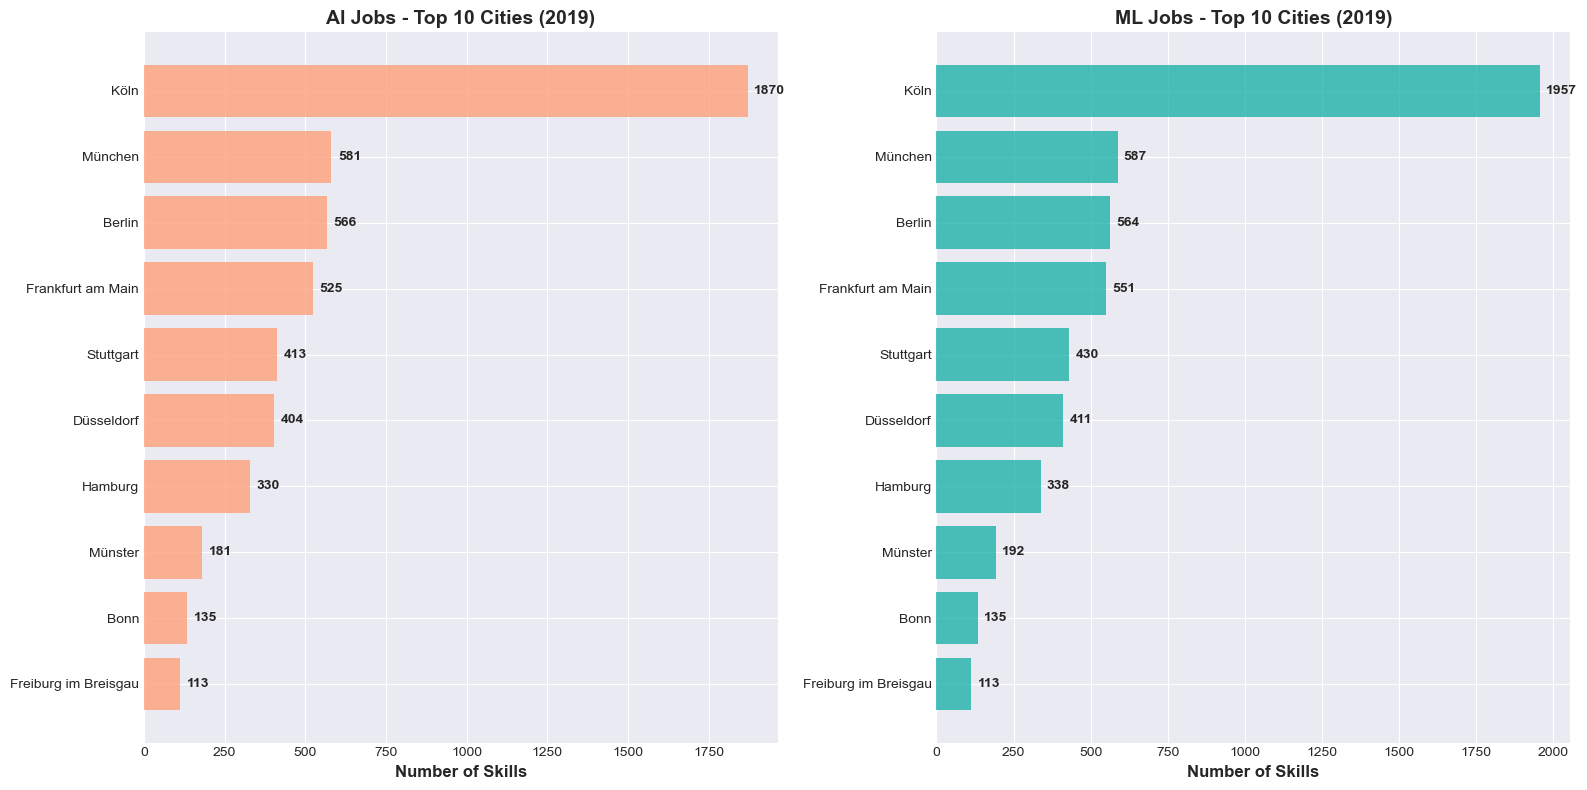

✔ Created: comparison_cities_AI_vs_ML_2019.pdf/png


In [76]:
# ============================================================
# 3. CITY COMPARISON - AI vs ML for 2019
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# AI Cities 2019
top_ai_city_2019 = ai_city_2019.head(10)
ax1.barh(top_ai_city_2019['city'], top_ai_city_2019['count'], color='#FFA07A', alpha=0.8)
ax1.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax1.set_title('AI Jobs - Top 10 Cities (2019)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top_ai_city_2019['count']):
    ax1.text(v + 20, i, str(v), va='center', fontweight='bold')

# ML Cities 2019
top_ml_city_2019 = ml_city_2019.head(10)
ax2.barh(top_ml_city_2019['city'], top_ml_city_2019['count'], color='#20B2AA', alpha=0.8)
ax2.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax2.set_title('ML Jobs - Top 10 Cities (2019)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(top_ml_city_2019['count']):
    ax2.text(v + 20, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'comparison_cities_AI_vs_ML_2019.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'comparison_cities_AI_vs_ML_2019.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: comparison_cities_AI_vs_ML_2019.pdf/png")

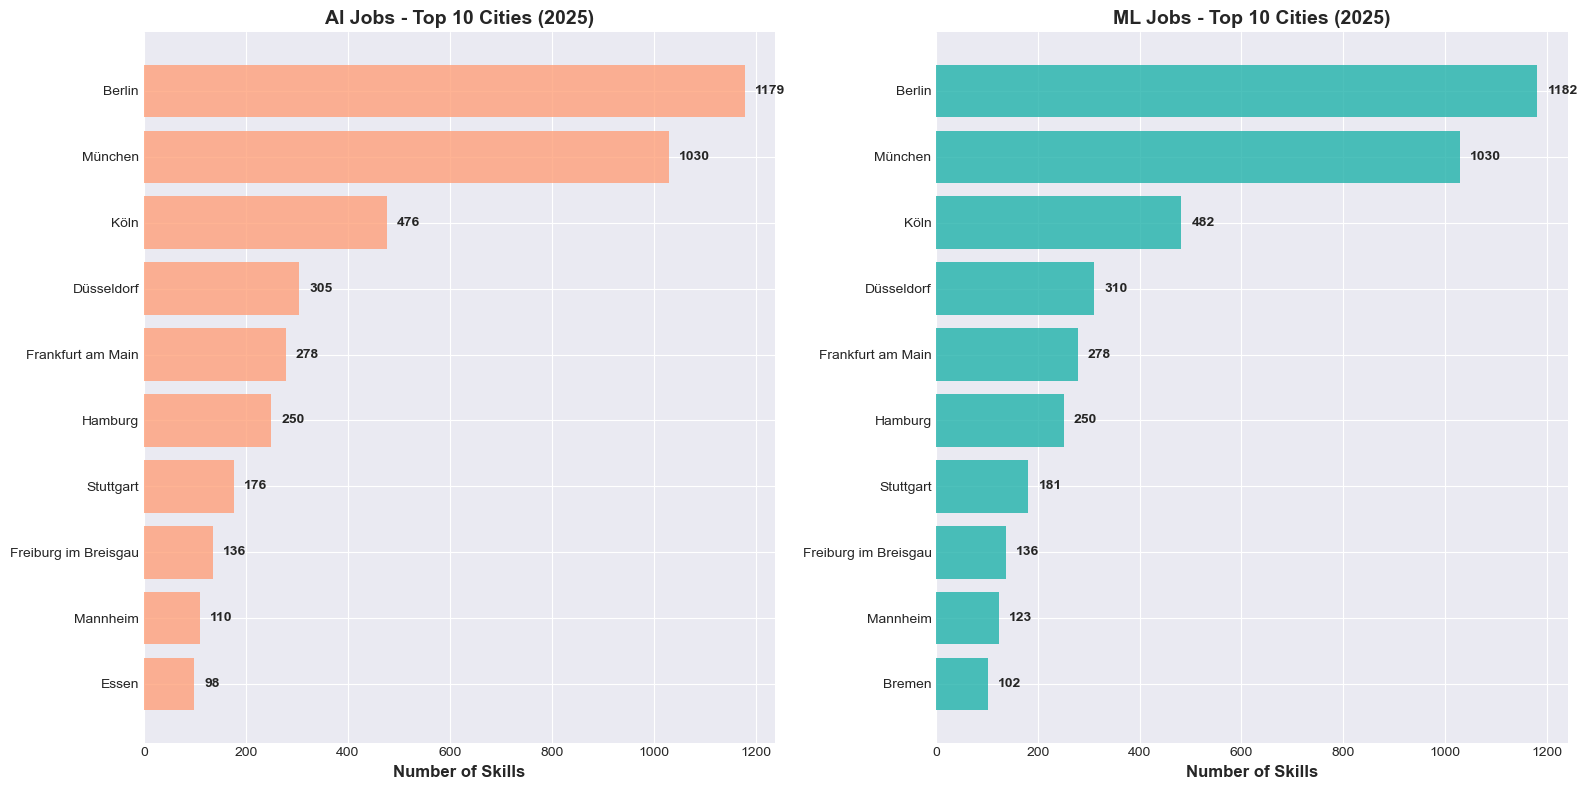

✔ Created: comparison_cities_AI_vs_ML_2025.pdf/png


In [77]:
# ============================================================
# 4. CITY COMPARISON - AI vs ML for 2025
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# AI Cities 2025
top_ai_city_2025 = ai_city_2025.head(10)
ax1.barh(top_ai_city_2025['city'], top_ai_city_2025['count'], color='#FFA07A', alpha=0.8)
ax1.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax1.set_title('AI Jobs - Top 10 Cities (2025)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top_ai_city_2025['count']):
    ax1.text(v + 20, i, str(v), va='center', fontweight='bold')

# ML Cities 2025
top_ml_city_2025 = ml_city_2025.head(10)
ax2.barh(top_ml_city_2025['city'], top_ml_city_2025['count'], color='#20B2AA', alpha=0.8)
ax2.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax2.set_title('ML Jobs - Top 10 Cities (2025)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(top_ml_city_2025['count']):
    ax2.text(v + 20, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'comparison_cities_AI_vs_ML_2025.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'comparison_cities_AI_vs_ML_2025.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: comparison_cities_AI_vs_ML_2025.pdf/png")

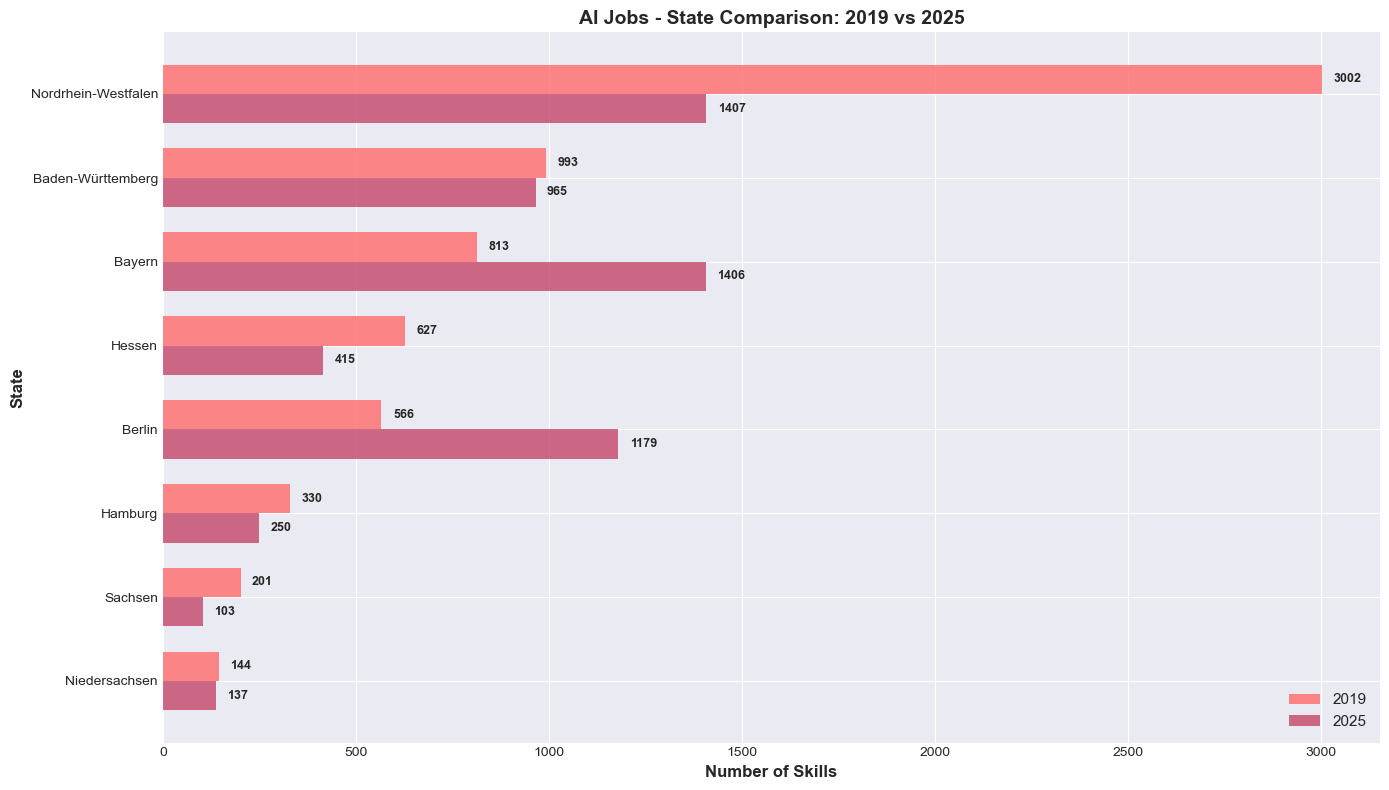

✔ Created: temporal_comparison_AI_states_2019_vs_2025.pdf/png


In [78]:
# ============================================================
# 5. TEMPORAL COMPARISON - States: 2019 vs 2025 (AI)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Get top 8 states from 2019 AI data
top_states = ai_state_2019.head(8)['state'].tolist()

# Prepare data for these states in both years
ai_2019_vals = []
ai_2025_vals = []

for state in top_states:
    val_2019 = ai_state_2019[ai_state_2019['state'] == state]['count'].values
    val_2025 = ai_state_2025[ai_state_2025['state'] == state]['count'].values
    
    ai_2019_vals.append(val_2019[0] if len(val_2019) > 0 else 0)
    ai_2025_vals.append(val_2025[0] if len(val_2025) > 0 else 0)

x = np.arange(len(top_states))
width = 0.35

bars1 = ax.barh(x - width/2, ai_2019_vals, width, label='2019', color='#FF6B6B', alpha=0.8)
bars2 = ax.barh(x + width/2, ai_2025_vals, width, label='2025', color='#C44569', alpha=0.8)

ax.set_ylabel('State', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax.set_title('AI Jobs - State Comparison: 2019 vs 2025', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(top_states)
ax.legend(fontsize=11)
ax.invert_yaxis()

# Add value labels
for i, (v1, v2) in enumerate(zip(ai_2019_vals, ai_2025_vals)):
    ax.text(v1 + 30, i - width/2, str(v1), va='center', fontweight='bold', fontsize=9)
    ax.text(v2 + 30, i + width/2, str(v2), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_AI_states_2019_vs_2025.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_AI_states_2019_vs_2025.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: temporal_comparison_AI_states_2019_vs_2025.pdf/png")

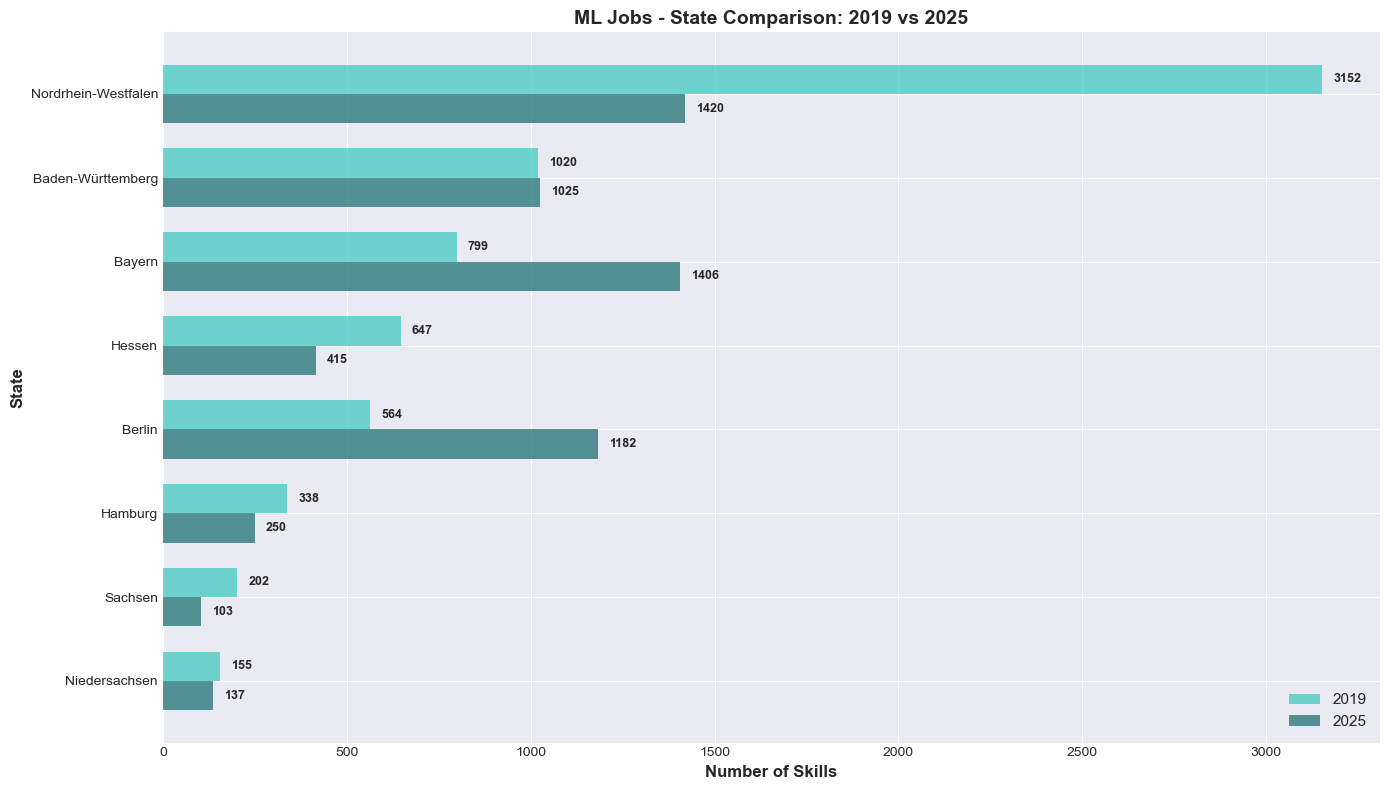

✔ Created: temporal_comparison_ML_states_2019_vs_2025.pdf/png


In [79]:
# ============================================================
# 6. TEMPORAL COMPARISON - States: 2019 vs 2025 (ML)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Get top 8 states from 2019 ML data
top_states_ml = ml_state_2019.head(8)['state'].tolist()

# Prepare data for these states in both years
ml_2019_vals = []
ml_2025_vals = []

for state in top_states_ml:
    val_2019 = ml_state_2019[ml_state_2019['state'] == state]['count'].values
    val_2025 = ml_state_2025[ml_state_2025['state'] == state]['count'].values
    
    ml_2019_vals.append(val_2019[0] if len(val_2019) > 0 else 0)
    ml_2025_vals.append(val_2025[0] if len(val_2025) > 0 else 0)

x = np.arange(len(top_states_ml))
width = 0.35

bars1 = ax.barh(x - width/2, ml_2019_vals, width, label='2019', color='#4ECDC4', alpha=0.8)
bars2 = ax.barh(x + width/2, ml_2025_vals, width, label='2025', color='#2C7A7B', alpha=0.8)

ax.set_ylabel('State', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax.set_title('ML Jobs - State Comparison: 2019 vs 2025', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(top_states_ml)
ax.legend(fontsize=11)
ax.invert_yaxis()

# Add value labels
for i, (v1, v2) in enumerate(zip(ml_2019_vals, ml_2025_vals)):
    ax.text(v1 + 30, i - width/2, str(v1), va='center', fontweight='bold', fontsize=9)
    ax.text(v2 + 30, i + width/2, str(v2), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_ML_states_2019_vs_2025.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_ML_states_2019_vs_2025.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: temporal_comparison_ML_states_2019_vs_2025.pdf/png")

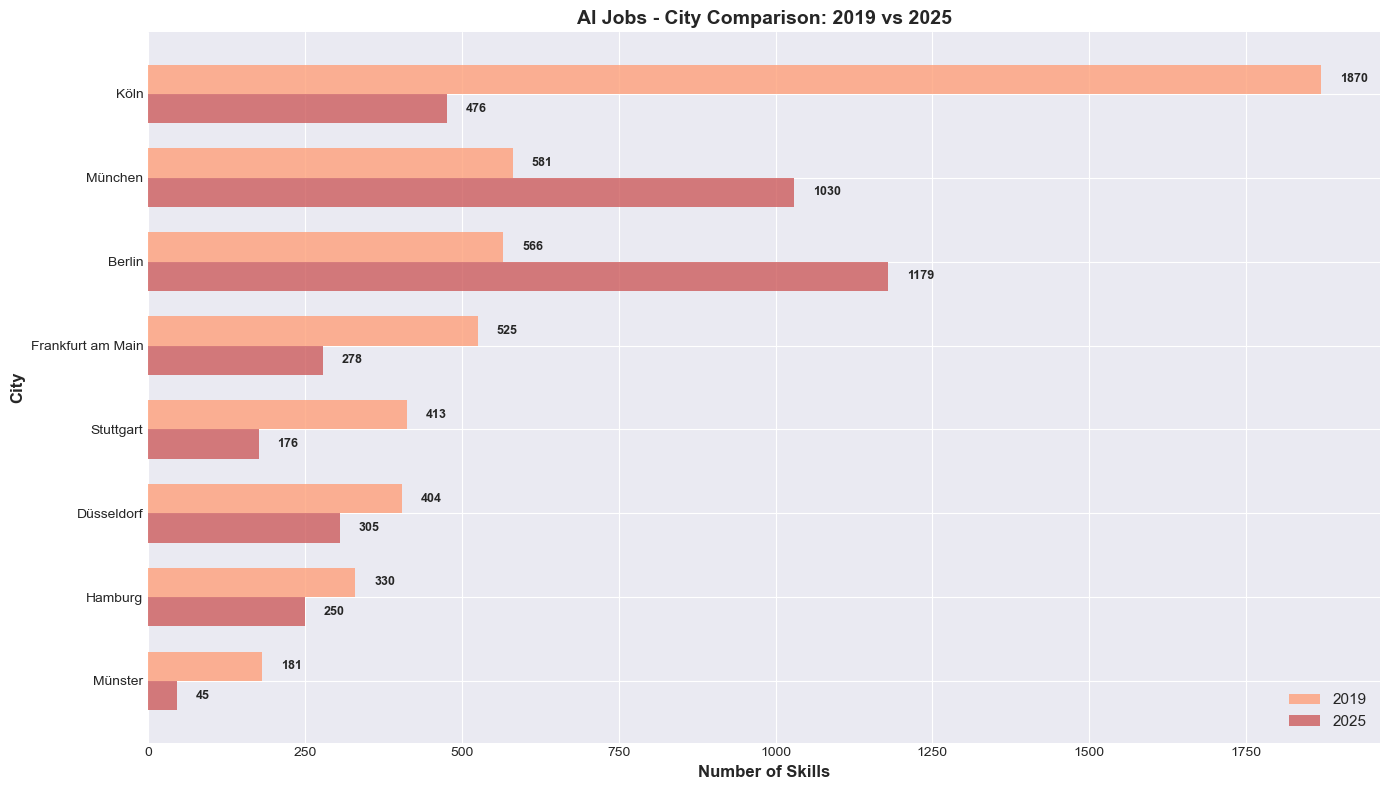

✔ Created: temporal_comparison_AI_cities_2019_vs_2025.pdf/png


In [80]:
# ============================================================
# 7. TEMPORAL COMPARISON - Cities: 2019 vs 2025 (AI)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Get top 8 cities from 2019 AI data
top_cities = ai_city_2019.head(8)['city'].tolist()

# Prepare data for these cities in both years
ai_city_2019_vals = []
ai_city_2025_vals = []

for city in top_cities:
    val_2019 = ai_city_2019[ai_city_2019['city'] == city]['count'].values
    val_2025 = ai_city_2025[ai_city_2025['city'] == city]['count'].values
    
    ai_city_2019_vals.append(val_2019[0] if len(val_2019) > 0 else 0)
    ai_city_2025_vals.append(val_2025[0] if len(val_2025) > 0 else 0)

x = np.arange(len(top_cities))
width = 0.35

bars1 = ax.barh(x - width/2, ai_city_2019_vals, width, label='2019', color='#FFA07A', alpha=0.8)
bars2 = ax.barh(x + width/2, ai_city_2025_vals, width, label='2025', color='#CD5C5C', alpha=0.8)

ax.set_ylabel('City', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax.set_title('AI Jobs - City Comparison: 2019 vs 2025', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(top_cities)
ax.legend(fontsize=11)
ax.invert_yaxis()

# Add value labels
for i, (v1, v2) in enumerate(zip(ai_city_2019_vals, ai_city_2025_vals)):
    ax.text(v1 + 30, i - width/2, str(v1), va='center', fontweight='bold', fontsize=9)
    ax.text(v2 + 30, i + width/2, str(v2), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_AI_cities_2019_vs_2025.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_AI_cities_2019_vs_2025.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: temporal_comparison_AI_cities_2019_vs_2025.pdf/png")

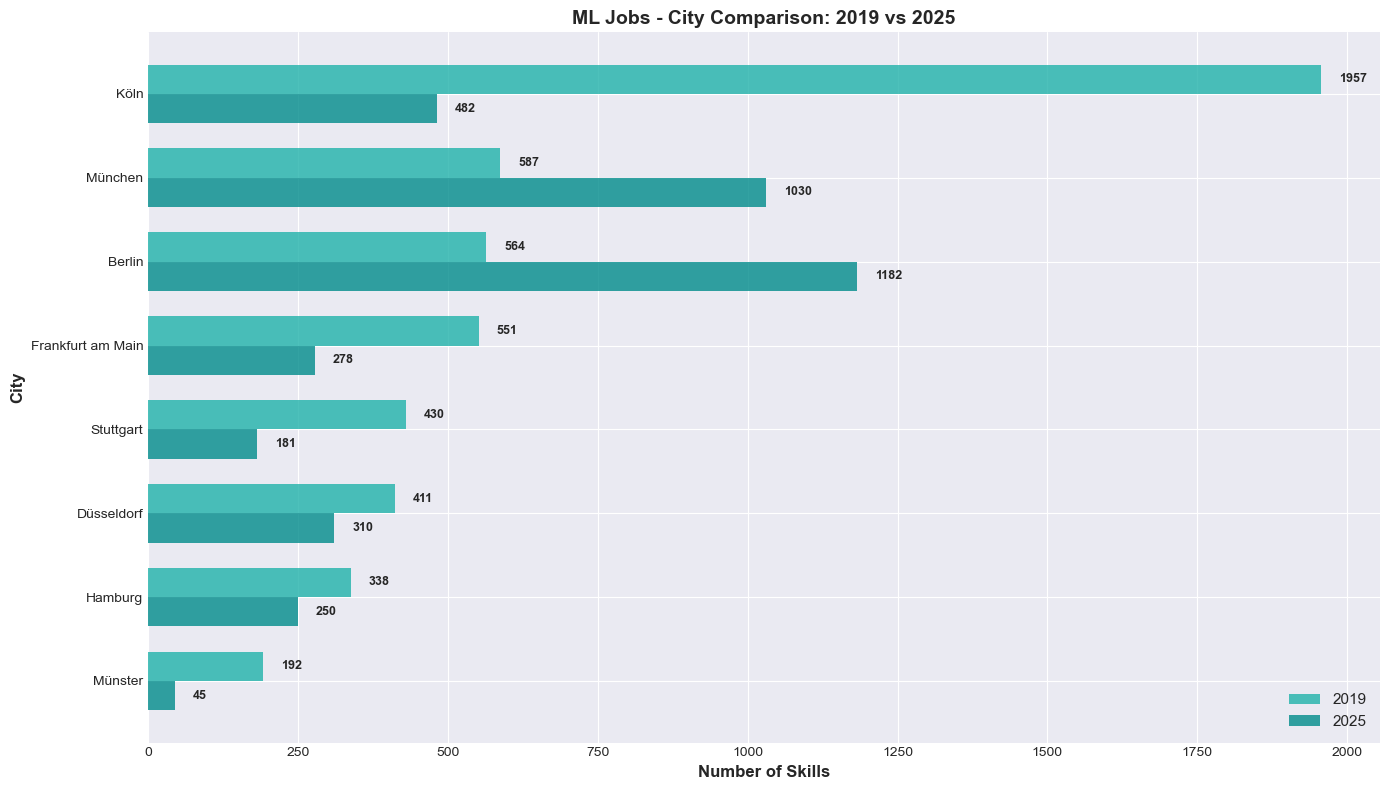

✔ Created: temporal_comparison_ML_cities_2019_vs_2025.pdf/png


In [81]:
# ============================================================
# 8. TEMPORAL COMPARISON - Cities: 2019 vs 2025 (ML)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Get top 8 cities from 2019 ML data
top_cities_ml = ml_city_2019.head(8)['city'].tolist()

# Prepare data for these cities in both years
ml_city_2019_vals = []
ml_city_2025_vals = []

for city in top_cities_ml:
    val_2019 = ml_city_2019[ml_city_2019['city'] == city]['count'].values
    val_2025 = ml_city_2025[ml_city_2025['city'] == city]['count'].values
    
    ml_city_2019_vals.append(val_2019[0] if len(val_2019) > 0 else 0)
    ml_city_2025_vals.append(val_2025[0] if len(val_2025) > 0 else 0)

x = np.arange(len(top_cities_ml))
width = 0.35

bars1 = ax.barh(x - width/2, ml_city_2019_vals, width, label='2019', color='#20B2AA', alpha=0.8)
bars2 = ax.barh(x + width/2, ml_city_2025_vals, width, label='2025', color='#008B8B', alpha=0.8)

ax.set_ylabel('City', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Skills', fontsize=12, fontweight='bold')
ax.set_title('ML Jobs - City Comparison: 2019 vs 2025', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(top_cities_ml)
ax.legend(fontsize=11)
ax.invert_yaxis()

# Add value labels
for i, (v1, v2) in enumerate(zip(ml_city_2019_vals, ml_city_2025_vals)):
    ax.text(v1 + 30, i - width/2, str(v1), va='center', fontweight='bold', fontsize=9)
    ax.text(v2 + 30, i + width/2, str(v2), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_ML_cities_2019_vs_2025.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(visualizations_dir, 'temporal_comparison_ML_cities_2019_vs_2025.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✔ Created: temporal_comparison_ML_cities_2019_vs_2025.pdf/png")

In [46]:
# ============================================================
# SUMMARY: All Graphs Created
# ============================================================

print("\n" + "="*70)
print("VISUALIZATION SUMMARY - AI vs ML Comparison")
print("="*70)
print("\n✔ All graphs have been created successfully!")
print("\nFiles created:")
print("\n📊 STATE COMPARISONS (Side-by-side AI vs ML):")
print("  1. comparison_states_AI_vs_ML_2019.pdf/png")
print("  2. comparison_states_AI_vs_ML_2025.pdf/png")
print("\n📊 CITY COMPARISONS (Side-by-side AI vs ML):")
print("  3. comparison_cities_AI_vs_ML_2019.pdf/png")
print("  4. comparison_cities_AI_vs_ML_2025.pdf/png")
print("\n📊 TEMPORAL COMPARISONS - STATES (2019 vs 2025):")
print("  5. temporal_comparison_AI_states_2019_vs_2025.pdf/png")
print("  6. temporal_comparison_ML_states_2019_vs_2025.pdf/png")
print("\n📊 TEMPORAL COMPARISONS - CITIES (2019 vs 2025):")
print("  7. temporal_comparison_AI_cities_2019_vs_2025.pdf/png")
print("  8. temporal_comparison_ML_cities_2019_vs_2025.pdf/png")
print("\n" + "="*70)
print(f"Total: 8 different comparison visualizations (16 files: PDF + PNG)")
print("="*70)


VISUALIZATION SUMMARY - AI vs ML Comparison

✔ All graphs have been created successfully!

Files created:

📊 STATE COMPARISONS (Side-by-side AI vs ML):
  1. comparison_states_AI_vs_ML_2019.pdf/png
  2. comparison_states_AI_vs_ML_2025.pdf/png

📊 CITY COMPARISONS (Side-by-side AI vs ML):
  3. comparison_cities_AI_vs_ML_2019.pdf/png
  4. comparison_cities_AI_vs_ML_2025.pdf/png

📊 TEMPORAL COMPARISONS - STATES (2019 vs 2025):
  5. temporal_comparison_AI_states_2019_vs_2025.pdf/png
  6. temporal_comparison_ML_states_2019_vs_2025.pdf/png

📊 TEMPORAL COMPARISONS - CITIES (2019 vs 2025):
  7. temporal_comparison_AI_cities_2019_vs_2025.pdf/png
  8. temporal_comparison_ML_cities_2019_vs_2025.pdf/png

Total: 8 different comparison visualizations (16 files: PDF + PNG)


# Create Tables for Analysis

This section creates tables similar to the reference tables:
- **Table 2**: Geographical distribution of AI and ML jobs by state
- **Table 3**: Top categories/majors for AI and ML jobs
- **Table 4**: Skill distribution for AI positions
- **Table 5**: Skill distribution for ML positions

In [66]:
# Define output directories
import os

# Main results folder
results_dir = "/Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_analysis/results"
os.makedirs(results_dir, exist_ok=True)

# Create subdirectories for organization
tables_dir = os.path.join(results_dir, "tables")
distributions_dir = os.path.join(results_dir, "distributions")
visualizations_dir = os.path.join(results_dir, "visualizations")
raw_data_dir = os.path.join(results_dir, "raw_data")

for directory in [tables_dir, distributions_dir, visualizations_dir, raw_data_dir]:
    os.makedirs(directory, exist_ok=True)

# For backward compatibility
output_dir = tables_dir

print("📁 Results folder structure created:")
print(f"  Main: {results_dir}")
print(f"  ├── tables/          (Table 2-5 CSV files)")
print(f"  ├── distributions/   (City/State distributions)")
print(f"  ├── visualizations/  (PNG/PDF graphs)")
print(f"  └── raw_data/        (Full skill extractions)")
print("\n✔ All directories ready!")

📁 Results folder structure created:
  Main: /Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_analysis/results
  ├── tables/          (Table 2-5 CSV files)
  ├── distributions/   (City/State distributions)
  ├── visualizations/  (PNG/PDF graphs)
  └── raw_data/        (Full skill extractions)

✔ All directories ready!


In [70]:
# ============================================================
# TABLE 2: Geographical Distribution of Jobs by State
# Creating separate files for 2019 and 2025
# ============================================================

# Calculate job counts by state for 2019 and 2025
jobs_df = pd.read_csv("/Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/dataset/jobs_ai_ml_with_city_state_filled.csv")

# Separate 2019 and 2025 jobs
jobs_2019 = jobs_df[jobs_df['year'] == 2019]
jobs_2025 = jobs_df[jobs_df['year'] == 2025]

# ===== TABLE 2A: 2019 DATA =====
# Count jobs by state for 2019
state_counts_2019 = jobs_2019['state'].value_counts().reset_index()
state_counts_2019.columns = ['State', 'Job_count']

# Calculate total and percentage
total_2019 = state_counts_2019['Job_count'].sum()
state_counts_2019['Percentage'] = (state_counts_2019['Job_count'] / total_2019 * 100).round(2)

# Add rank
state_counts_2019 = state_counts_2019.sort_values('Job_count', ascending=False).reset_index(drop=True)
state_counts_2019['Rank'] = range(1, len(state_counts_2019) + 1)
state_counts_2019 = state_counts_2019[['Rank', 'State', 'Job_count', 'Percentage']]

# Display and save
print("Table 2A: Geographical Distribution of Jobs by State (2019)")
print("="*80)
print(state_counts_2019.head(10).to_string(index=False))
print()

output_file_2019 = os.path.join(output_dir, 'table2_geographical_distribution_2019.csv')
state_counts_2019.to_csv(output_file_2019, index=False)
print(f"✔ Saved: {output_file_2019}")
print()

# ===== TABLE 2B: 2025 DATA =====
# Count jobs by state for 2025
state_counts_2025 = jobs_2025['state'].value_counts().reset_index()
state_counts_2025.columns = ['State', 'Job_count']

# Calculate total and percentage
total_2025 = state_counts_2025['Job_count'].sum()
state_counts_2025['Percentage'] = (state_counts_2025['Job_count'] / total_2025 * 100).round(2)

# Add rank
state_counts_2025 = state_counts_2025.sort_values('Job_count', ascending=False).reset_index(drop=True)
state_counts_2025['Rank'] = range(1, len(state_counts_2025) + 1)
state_counts_2025 = state_counts_2025[['Rank', 'State', 'Job_count', 'Percentage']]

# Display and save
print("Table 2B: Geographical Distribution of Jobs by State (2025)")
print("="*80)
print(state_counts_2025.head(10).to_string(index=False))
print()

output_file_2025 = os.path.join(output_dir, 'table2_geographical_distribution_2025.csv')
state_counts_2025.to_csv(output_file_2025, index=False)
print(f"✔ Saved: {output_file_2025}")
print()

Table 2A: Geographical Distribution of Jobs by State (2019)
 Rank               State  Job_count  Percentage
    1 Nordrhein-Westfalen        296       43.66
    2   Baden-Württemberg        103       15.19
    3              Bayern         85       12.54
    4              Hessen         57        8.41
    5              Berlin         53        7.82
    6             Hamburg         33        4.87
    7             Sachsen         18        2.65
    8       Niedersachsen         12        1.77
    9  Schleswig-Holstein          7        1.03
   10     Rheinland-Pfalz          6        0.88

✔ Saved: /Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_analysis/results/tables/table2_geographical_distribution_2019.csv

Table 2B: Geographical Distribution of Jobs by State (2025)
 Rank               State  Job_count  Percentage
    1 Nordrhein-Westfalen        162       21.51
    2              Bayern        155       20.58
    3              Berlin        141       18.73
 

In [71]:
# ============================================================
# TABLE 3: Top Categories (Majors) Required
# Creating separate files for 2019 and 2025
# ============================================================

# ===== TABLE 3A: 2019 DATA =====
# Count skills by category for 2019
categories_2019 = skill_df_with_domain[skill_df_with_domain['year'] == 2019]['category'].value_counts().reset_index()
categories_2019.columns = ['Category', 'Count']

# Calculate total and percentage
total_2019_skills = categories_2019['Count'].sum()
categories_2019['Percentage'] = (categories_2019['Count'] / total_2019_skills * 100).round(2)

# Add rank
categories_2019 = categories_2019.sort_values('Count', ascending=False).reset_index(drop=True)
categories_2019['Rank'] = range(1, len(categories_2019) + 1)
categories_2019 = categories_2019[['Rank', 'Category', 'Count', 'Percentage']]

# Display and save
print("Table 3A: Top Categories (Majors) Required for 2019")
print("="*80)
print(categories_2019.head(10).to_string(index=False))
print()

output_file_2019 = os.path.join(output_dir, 'table3_top_categories_2019.csv')
categories_2019.to_csv(output_file_2019, index=False)
print(f"✔ Saved: {output_file_2019}")
print()

# ===== TABLE 3B: 2025 DATA =====
# Count skills by category for 2025
categories_2025 = skill_df_with_domain[skill_df_with_domain['year'] == 2025]['category'].value_counts().reset_index()
categories_2025.columns = ['Category', 'Count']

# Calculate total and percentage
total_2025_skills = categories_2025['Count'].sum()
categories_2025['Percentage'] = (categories_2025['Count'] / total_2025_skills * 100).round(2)

# Add rank
categories_2025 = categories_2025.sort_values('Count', ascending=False).reset_index(drop=True)
categories_2025['Rank'] = range(1, len(categories_2025) + 1)
categories_2025 = categories_2025[['Rank', 'Category', 'Count', 'Percentage']]

# Display and save
print("Table 3B: Top Categories (Majors) Required for 2025")
print("="*80)
print(categories_2025.head(10).to_string(index=False))
print()

output_file_2025 = os.path.join(output_dir, 'table3_top_categories_2025.csv')
categories_2025.to_csv(output_file_2025, index=False)
print(f"✔ Saved: {output_file_2025}")
print()

Table 3A: Top Categories (Majors) Required for 2019
 Rank                       Category  Count  Percentage
    1            Statistics and Data   3139       41.17
    2 Decision Making and Analytical   1796       23.56
    3        Occupational Attributes   1401       18.38
    4                        General    771       10.11
    5                  Communication    188        2.47
    6                 Specialized ML    153        2.01
    7                Cloud Platforms     98        1.29
    8               Data Engineering     39        0.51
    9                          MLOps     27        0.35
   10            Employee Attributes      8        0.10

✔ Saved: /Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_analysis/results/tables/table3_top_categories_2019.csv

Table 3B: Top Categories (Majors) Required for 2025
 Rank                       Category  Count  Percentage
    1 Decision Making and Analytical   1730       26.48
    2        Occupational Attribute

In [72]:
# ============================================================
# TABLE 4: Skills Distribution by Year
# Creating separate files for 2019 and 2025
# ============================================================

# ===== TABLE 4A: 2019 DATA =====
# Filter for 2019 jobs
skills_2019 = skill_df_with_domain[skill_df_with_domain['year'] == 2019].copy()

# Count skills by category and subcategory
skill_counts_2019 = skills_2019.groupby(['category', 'subcategory', 'skill']).size().reset_index(name='count')

# Calculate total skills
total_skills_2019 = skill_counts_2019['count'].sum()

# Calculate percentage
skill_counts_2019['percentage'] = (skill_counts_2019['count'] / total_skills_2019 * 100).round(2)

# Sort by count
skill_counts_2019 = skill_counts_2019.sort_values('count', ascending=False).reset_index(drop=True)

# Group by category for hierarchical view
table4_2019 = []
for category in skill_counts_2019['category'].unique()[:10]:  # Top 10 categories
    cat_data = skill_counts_2019[skill_counts_2019['category'] == category]
    
    # Get top 5 skills in this category
    top_skills = cat_data.head(5)
    
    for _, skill_row in top_skills.iterrows():
        table4_2019.append({
            'Skill_category': category,
            'Skill': skill_row['skill'],
            'Count': skill_row['count'],
            'Percentage': skill_row['percentage']
        })

table4_2019_df = pd.DataFrame(table4_2019)

print("Table 4A: Skills Distribution for 2019")
print("="*80)
print(table4_2019_df.head(30).to_string(index=False))
print()

# Save to file
output_file_2019 = os.path.join(output_dir, 'table4_skills_2019.csv')
table4_2019_df.to_csv(output_file_2019, index=False)
print(f"✔ Saved: {output_file_2019}")
print()

# ===== TABLE 4B: 2025 DATA =====
# Filter for 2025 jobs
skills_2025 = skill_df_with_domain[skill_df_with_domain['year'] == 2025].copy()

# Count skills by category and subcategory
skill_counts_2025 = skills_2025.groupby(['category', 'subcategory', 'skill']).size().reset_index(name='count')

# Calculate total skills
total_skills_2025 = skill_counts_2025['count'].sum()

# Calculate percentage
skill_counts_2025['percentage'] = (skill_counts_2025['count'] / total_skills_2025 * 100).round(2)

# Sort by count
skill_counts_2025 = skill_counts_2025.sort_values('count', ascending=False).reset_index(drop=True)

# Group by category for hierarchical view
table4_2025 = []
for category in skill_counts_2025['category'].unique()[:10]:  # Top 10 categories
    cat_data = skill_counts_2025[skill_counts_2025['category'] == category]
    
    # Get top 5 skills in this category
    top_skills = cat_data.head(5)
    
    for _, skill_row in top_skills.iterrows():
        table4_2025.append({
            'Skill_category': category,
            'Skill': skill_row['skill'],
            'Count': skill_row['count'],
            'Percentage': skill_row['percentage']
        })

table4_2025_df = pd.DataFrame(table4_2025)

print("Table 4B: Skills Distribution for 2025")
print("="*80)
print(table4_2025_df.head(30).to_string(index=False))
print()

# Save to file
output_file_2025 = os.path.join(output_dir, 'table4_skills_2025.csv')
table4_2025_df.to_csv(output_file_2025, index=False)
print(f"✔ Saved: {output_file_2025}")
print()

Table 4A: Skills Distribution for 2019
                Skill_category            Skill  Count  Percentage
           Statistics and Data machine learning   1311       17.20
           Statistics and Data              sql    672        8.81
           Statistics and Data           pandas    337        4.42
           Statistics and Data        statistik    215        2.82
           Statistics and Data         big data    194        2.54
       Occupational Attributes           python    815       10.69
       Occupational Attributes      integration    285        3.74
       Occupational Attributes              sap     74        0.97
       Occupational Attributes          tableau     59        0.77
       Occupational Attributes   programmierung     35        0.46
Decision Making and Analytical  implementierung    597        7.83
Decision Making and Analytical          analyse    561        7.36
Decision Making and Analytical   zusammenarbeit    476        6.24
Decision Making and Ana

In [73]:
# ============================================================
# TABLE 5: Top Skills by Category (Detailed View)
# Creating separate files for 2019 and 2025
# ============================================================

# ===== TABLE 5A: 2019 DATA =====
# Get top 10 skills overall for 2019
skills_2019_top = skill_df_with_domain[skill_df_with_domain['year'] == 2019].copy()
top_skills_2019 = skills_2019_top['skill'].value_counts().head(30).reset_index()
top_skills_2019.columns = ['Skill', 'Count']

# Add category information
skill_to_cat_2019 = skills_2019_top.groupby('skill')['category'].first().to_dict()
top_skills_2019['Category'] = top_skills_2019['Skill'].map(skill_to_cat_2019)

# Calculate percentage
total_2019 = top_skills_2019['Count'].sum()
top_skills_2019['Percentage'] = (top_skills_2019['Count'] / skills_2019_top.shape[0] * 100).round(2)

# Add rank
top_skills_2019['Rank'] = range(1, len(top_skills_2019) + 1)
top_skills_2019 = top_skills_2019[['Rank', 'Category', 'Skill', 'Count', 'Percentage']]

print("Table 5A: Top Skills for 2019")
print("="*80)
print(top_skills_2019.head(30).to_string(index=False))
print()

# Save to file
output_file_2019 = os.path.join(output_dir, 'table5_top_skills_2019.csv')
top_skills_2019.to_csv(output_file_2019, index=False)
print(f"✔ Saved: {output_file_2019}")
print()

# ===== TABLE 5B: 2025 DATA =====
# Get top 10 skills overall for 2025
skills_2025_top = skill_df_with_domain[skill_df_with_domain['year'] == 2025].copy()
top_skills_2025 = skills_2025_top['skill'].value_counts().head(30).reset_index()
top_skills_2025.columns = ['Skill', 'Count']

# Add category information
skill_to_cat_2025 = skills_2025_top.groupby('skill')['category'].first().to_dict()
top_skills_2025['Category'] = top_skills_2025['Skill'].map(skill_to_cat_2025)

# Calculate percentage
total_2025 = top_skills_2025['Count'].sum()
top_skills_2025['Percentage'] = (top_skills_2025['Count'] / skills_2025_top.shape[0] * 100).round(2)

# Add rank
top_skills_2025['Rank'] = range(1, len(top_skills_2025) + 1)
top_skills_2025 = top_skills_2025[['Rank', 'Category', 'Skill', 'Count', 'Percentage']]

print("Table 5B: Top Skills for 2025")
print("="*80)
print(top_skills_2025.head(30).to_string(index=False))
print()

# Save to file
output_file_2025 = os.path.join(output_dir, 'table5_top_skills_2025.csv')
top_skills_2025.to_csv(output_file_2025, index=False)
print(f"✔ Saved: {output_file_2025}")
print()

Table 5A: Top Skills for 2019
 Rank                       Category            Skill  Count  Percentage
    1            Statistics and Data machine learning   1311       17.20
    2        Occupational Attributes           python    815       10.69
    3            Statistics and Data              sql    672        8.81
    4 Decision Making and Analytical  implementierung    597        7.83
    5 Decision Making and Analytical          analyse    561        7.36
    6 Decision Making and Analytical   zusammenarbeit    476        6.24
    7                        General       mathematik    357        4.68
    8                        General     datenanalyse    346        4.54
    9            Statistics and Data           pandas    337        4.42
   10        Occupational Attributes      integration    285        3.74
   11            Statistics and Data        statistik    215        2.82
   12            Statistics and Data         big data    194        2.54
   13                

In [65]:
# ============================================================
# Summary: All Tables Created
# ============================================================

print("="*80)
print("📊 ALL TABLES CREATED SUCCESSFULLY")
print("="*80)
print()
print("Created files:")
print("Table 2 - Geographical Distribution:")
print("  1. table2_geographical_distribution_2019.csv - Jobs by state (2019)")
print("  2. table2_geographical_distribution_2025.csv - Jobs by state (2025)")
print()
print("Table 3 - Top Skill Categories:")
print("  3. table3_top_categories_2019.csv - Category distribution (2019)")
print("  4. table3_top_categories_2025.csv - Category distribution (2025)")
print()
print("Table 4 - Skills by Category:")
print("  5. table4_skills_2019.csv - Detailed skills by category (2019)")
print("  6. table4_skills_2025.csv - Detailed skills by category (2025)")
print()
print("Table 5 - Top Skills:")
print("  7. table5_top_skills_2019.csv - Top individual skills (2019)")
print("  8. table5_top_skills_2025.csv - Top individual skills (2025)")
print()
print(f"All files saved in: {output_dir}")
print("="*80)

📊 ALL TABLES CREATED SUCCESSFULLY

Created files:
Table 2 - Geographical Distribution:
  1. table2_geographical_distribution_2019.csv - Jobs by state (2019)
  2. table2_geographical_distribution_2025.csv - Jobs by state (2025)

Table 3 - Top Skill Categories:
  3. table3_top_categories_2019.csv - Category distribution (2019)
  4. table3_top_categories_2025.csv - Category distribution (2025)

Table 4 - Skills by Category:
  5. table4_skills_2019.csv - Detailed skills by category (2019)
  6. table4_skills_2025.csv - Detailed skills by category (2025)

Table 5 - Top Skills:
  7. table5_top_skills_2019.csv - Top individual skills (2019)
  8. table5_top_skills_2025.csv - Top individual skills (2025)

All files saved in: /Users/shivangsinha/Downloads/Drive A/ThesisNov/Master_Thesis/BERT_analysis
